In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "CrabAgePrediction.csv" #can be easily changed from 'puter to 'puter
data = pd.read_csv(path, delimiter = ",")
#data["Sex"] = data["Sex"].map({"M": 1, "F": 2, "I": 3})

display(data)
data.shape

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6
...,...,...,...,...,...,...,...,...,...
3888,F,1.4625,1.1375,0.3250,24.819987,11.651644,5.854172,6.378637,8
3889,F,1.5500,1.2125,0.4375,34.458817,15.450477,7.172423,9.780577,10
3890,I,0.6250,0.4625,0.1625,2.012815,0.765436,0.524466,0.637864,5
3891,I,1.0625,0.7750,0.2625,10.347568,4.507570,2.338834,2.976698,6


(3893, 9)

In [186]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
rng_seed = 2434

counts = data["Age"].value_counts()
drop_classes = counts[counts < 3].index
data = data[data["Age"].isin(drop_classes) != True].copy()

data["Sex"] = data["Sex"].map({"M": 1, "F": 2, "I": 3})
features = data.columns.drop("Age")

In [187]:
Xtrain, Xtest, ytrain, ytest = train_test_split(data[features], data["Age"], train_size = 0.9, test_size = 0.1, random_state = rng_seed)

logreg_pipe = Pipeline([('scaler' , StandardScaler()), ('model' , LogisticRegression(random_state = rng_seed, solver = "saga", max_iter = 5000))])
logreg_pipe.fit(Xtrain, ytrain)

param_grid = {"model__penalty" : ["l1", "l2"], "model__C" : np.logspace(-3, 1, 5)}
gs_logreg = GridSearchCV(logreg_pipe, param_grid = param_grid, scoring = "accuracy", refit = "accuracy", cv = 3)
gs_logreg.fit(Xtrain, ytrain)

print(f"Best Parameters: {gs_logreg.best_params_}")
print(f"Final Test Accuracy: {gs_logreg.score(Xtest, ytest):.4f}")

Best Parameters: {'model__C': np.float64(1.0), 'model__penalty': 'l1'}
Final Test Accuracy: 0.2468


R squared: 0.12464066460379497


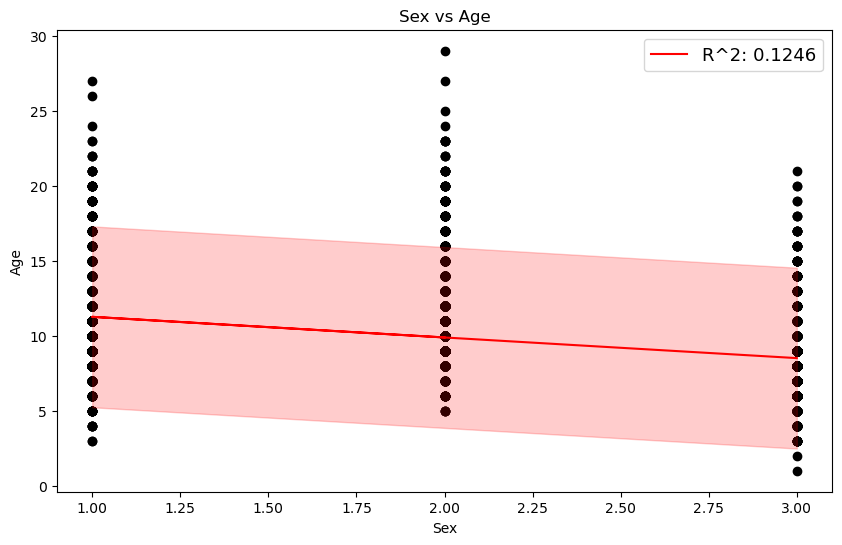

R squared: 0.307995345923039


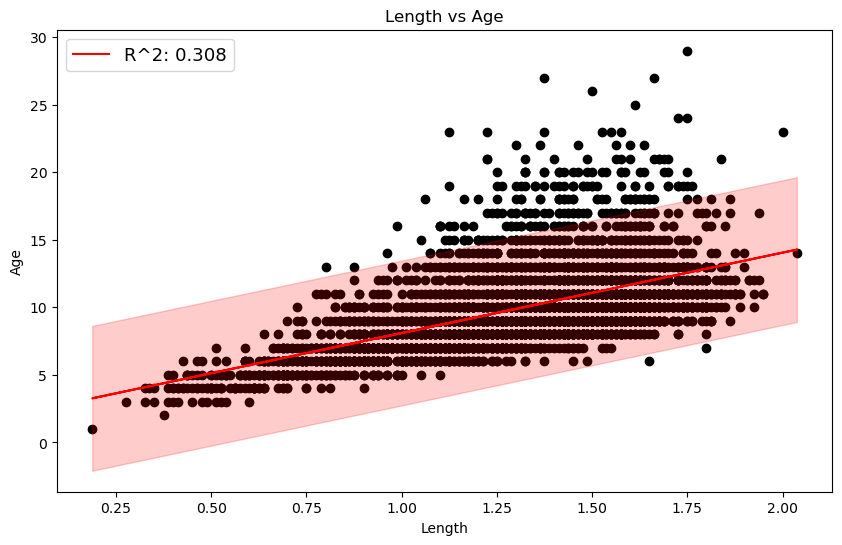

R squared: 0.32929729951164366


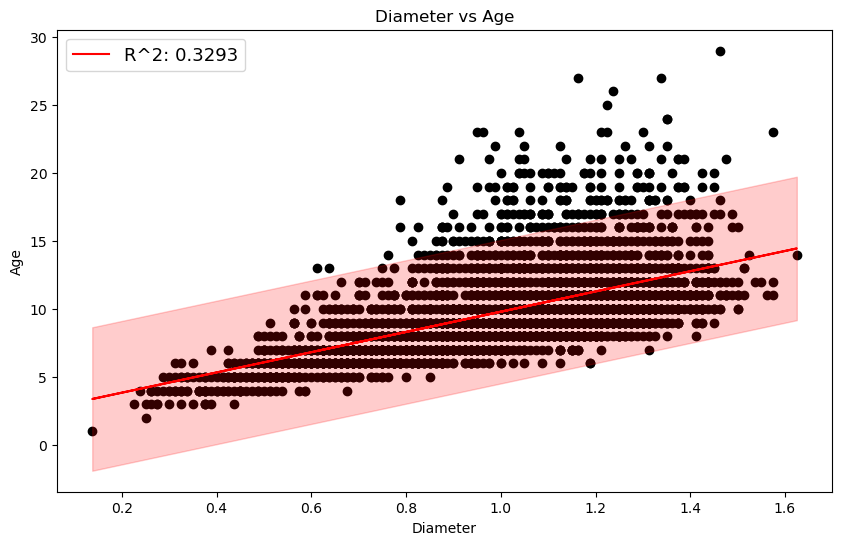

R squared: 0.3046558225235382


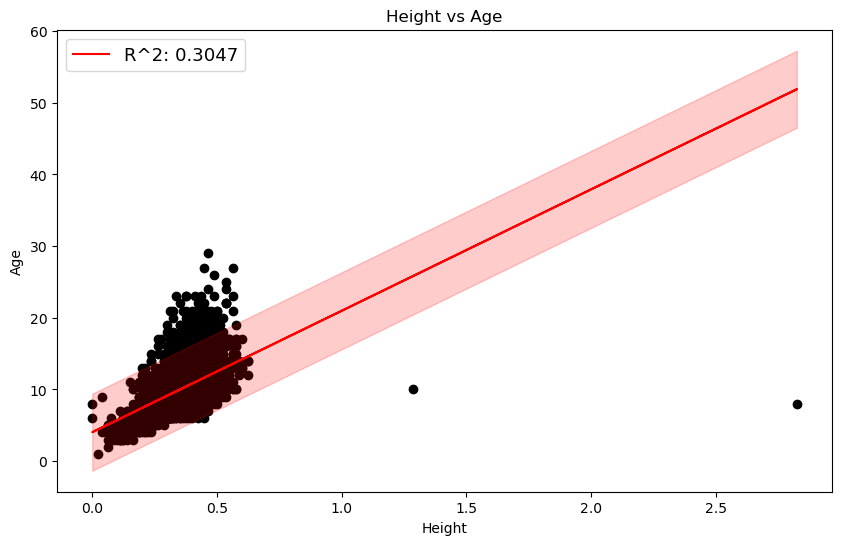

R squared: 0.2903263840043738


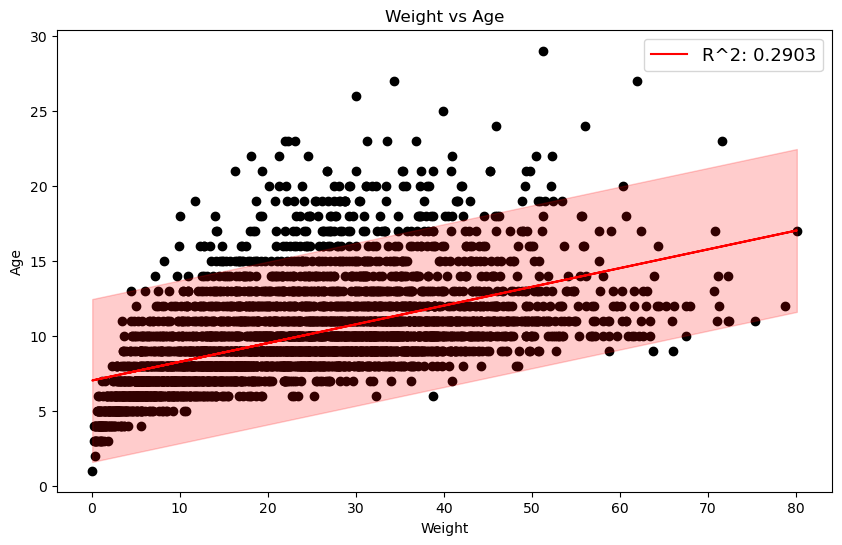

R squared: 0.175359747149602


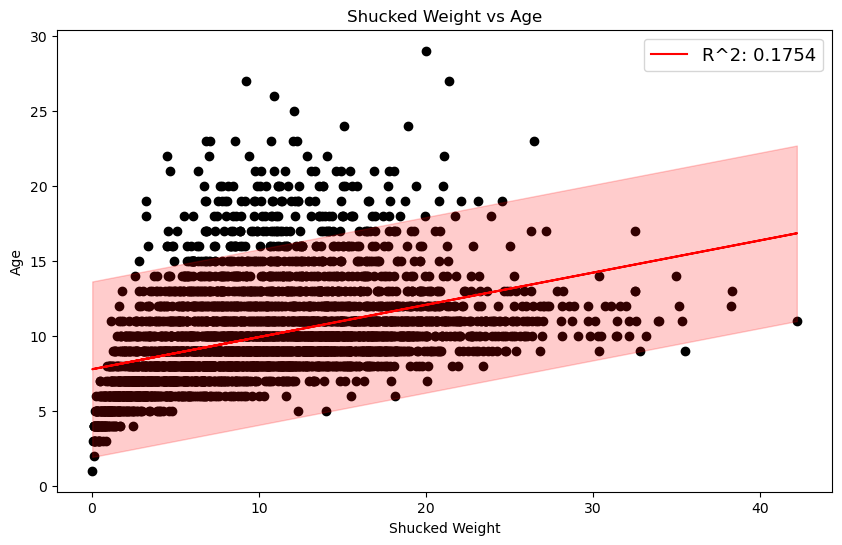

R squared: 0.25132953678746817


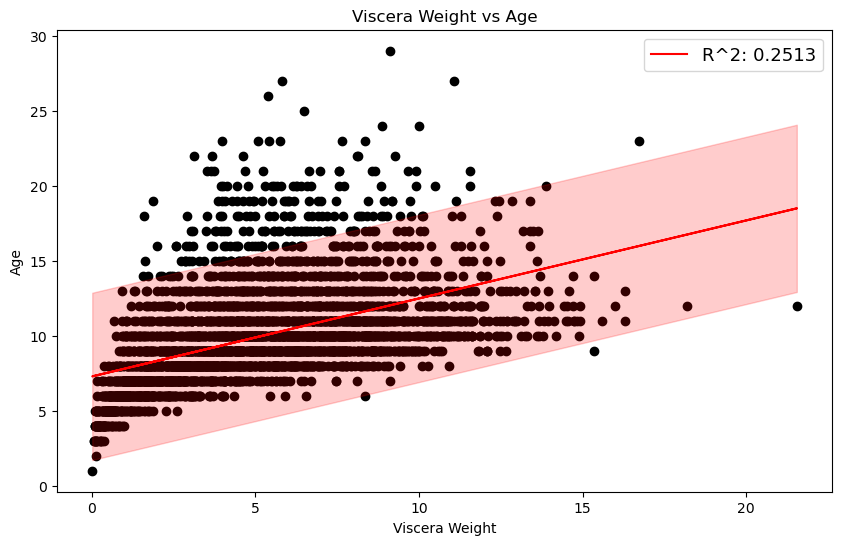

R squared: 0.39086878014369986


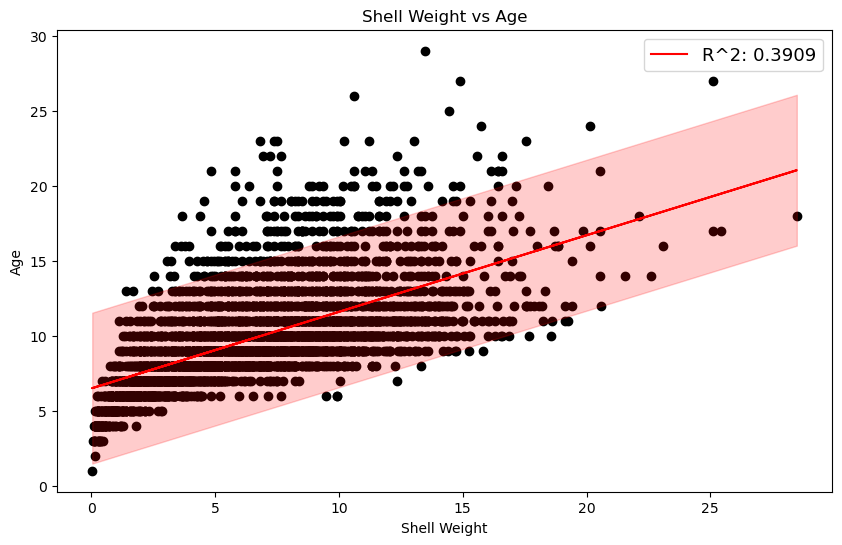

"\nlbda = -0.1\nx, y = DA\nphi = np.exp(lbda*x)\nDA2 = (phi,y)\nthetahatA2 = compute_linear_regression(DA2)\nRsquaredA2 = eval_Rsquared(thetahatA2,DA2)\n\nfig, ax = plt.subplots()\nax.scatter(DA[0],DA[1],color='k',marker='.')\nax.plot(DA[0],predict(thetahatA,DA[0]),label='$R^2$={:.3f}'.format(RsquaredA))\nax.plot(DA[0],predict(thetahatA2,DA2[0]),'-',label='$R^2$={:.3f}'.format(RsquaredA2))\nax.legend(fontsize=14)"

In [178]:
labelList = ["Sex", "Length", "Diameter", "Height", "Weight", "Shucked Weight", "Viscera Weight", "Shell Weight"]
N = 3893

for i in range(8):
    X = data.iloc[:, i]
    Y = data.iloc[:, -1]
    
    mean_X = sum(X) / N
    mean_Y = sum(Y) / N
    sigma_X = np.sqrt(sum((X - mean_X)**2) / (N - 1))
    sigma_Y = np.sqrt(sum((Y - mean_Y)**2) / (N - 1))
    sigma_XY = sum((X - mean_X) * (Y - mean_Y)) / (N - 1)
    
    thetahat_1 = sigma_XY / sigma_X**2
    thetahat_0 = mean_Y - (mean_X * thetahat_1)
    yhat = thetahat_0 + (X * thetahat_1)
    
    r_squared = 1 - (sum((Y - yhat)**2) / sum((Y - mean_Y)**2))
    print(f"R squared: {r_squared}")

    sigma2hat = sum((Y - yhat)**2) / (N - 2)
    sigma_X = np.sqrt(sum((X - mean_X)**2) / (N - 1))
    var_1 = sigma2hat / ((N - 1) * (sigma_X**2))
    var_0 = (sigma2hat / N) + ((sigma2hat * mean_X**2) / ((N - 1) * (sigma_X**2)))
    std_error = np.sqrt(sigma2hat)

    indSorted = np.argsort(X)
    XSorted = X[indSorted]
    yhatSorted = yhat[indSorted]
    
    plt.figure(figsize = (10, 6))
    plt.scatter(X, Y, color = "k")
    plt.plot(X, yhat, color = "r", label = "R^2: " + str(round(r_squared, 4)))
    plt.fill_between(XSorted, yhatSorted - 2 * std_error, yhatSorted + 2 * std_error, color = "r", alpha = 0.2)
    
    plt.title(labelList[i]+ " vs Age")
    plt.xlabel(labelList[i])
    plt.ylabel("Age")
    plt.legend(fontsize = 13)
    plt.show()


'''
lbda = -0.1
x, y = DA
phi = np.exp(lbda*x)
DA2 = (phi,y)
thetahatA2 = compute_linear_regression(DA2)
RsquaredA2 = eval_Rsquared(thetahatA2,DA2)

fig, ax = plt.subplots()
ax.scatter(DA[0],DA[1],color='k',marker='.')
ax.plot(DA[0],predict(thetahatA,DA[0]),label='$R^2$={:.3f}'.format(RsquaredA))
ax.plot(DA[0],predict(thetahatA2,DA2[0]),'-',label='$R^2$={:.3f}'.format(RsquaredA2))
ax.legend(fontsize=14)'''